# PyTorch Workflow Fundamentals

**Objective:** Build a linear regression model completely from scratch using
PyTorch — manually creating weights and bias as learnable parameters — to
understand exactly what's happening under the hood before using PyTorch's
built-in layers.

In [1]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

## Preparing and Loading Data

We create a simple synthetic dataset using a known formula
(`y = weight * X + bias`). Since we already know the true weight and bias,
we can check later whether the model actually learns them.

In [2]:
# creating known paramters
weight = 0.7
bias = 0.3

# create

start = 0
end = 1
step = 0.02

X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight*X + bias

X[:10] ,y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [3]:
print(f"The length of X is {len(X)}")
print(f"The length of y is {len(y)}")

The length of X is 50
The length of y is 50


## Splitting Data into Training and Test Sets

The model only sees the training data during learning. The test data is
held back so we can check whether it generalizes, instead of just
memorizing.

In [4]:
train_split = int(0.8*len(X))

X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train) ,len(y_train) , len(X_test) , len(y_test)

(40, 40, 10, 10)

## Visualizing the Data

Plotting the split confirms the training and test data look reasonable
before we build anything.

In [5]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None) :

  plt.figure(figsize=(10,6))

  plt.scatter(train_data,train_labels,c="b",s=4,label="Training Data")

  plt.scatter(test_data,test_labels,c="g",s=4,label="Testing Data")

  if predictions is not None:
    plt.scatter(test_data,predictions,c="r",s=4,label="Predictions")

  plt.legend(prop={"size":14});

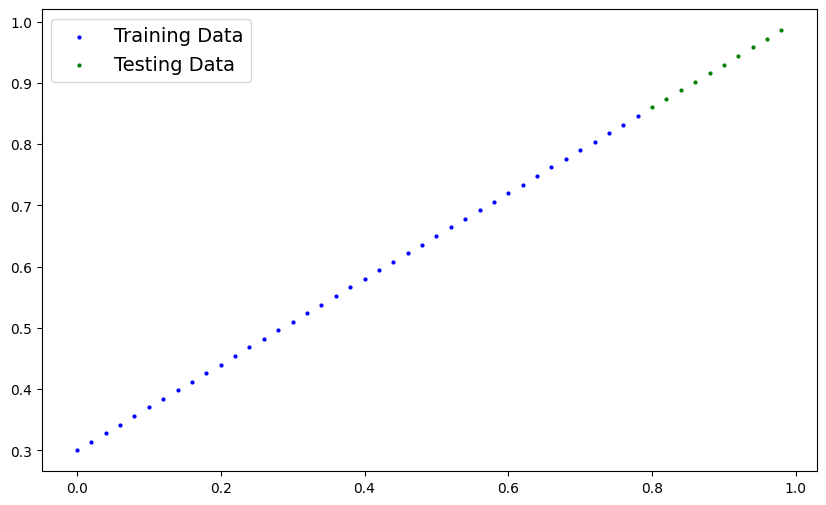

In [6]:
plot_predictions();

# Building the Model (From Scratch)

Instead of using `nn.Linear`, we manually create the weight and bias as
`nn.Parameter` objects. This is the same thing `nn.Linear` does internally
— building it manually here makes that clear.


In [7]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))

    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    return self.weights*x + self.bias

## Checking the Model's Initial (Untrained) Parameters

Before training, the weight and bias are randomly initialized. This is
what an untrained model looks like — its predictions at this point are
essentially guesses.

In [8]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [9]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [10]:
with torch.inference_mode():

  y_pred = model_0(X_test)

y_pred

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

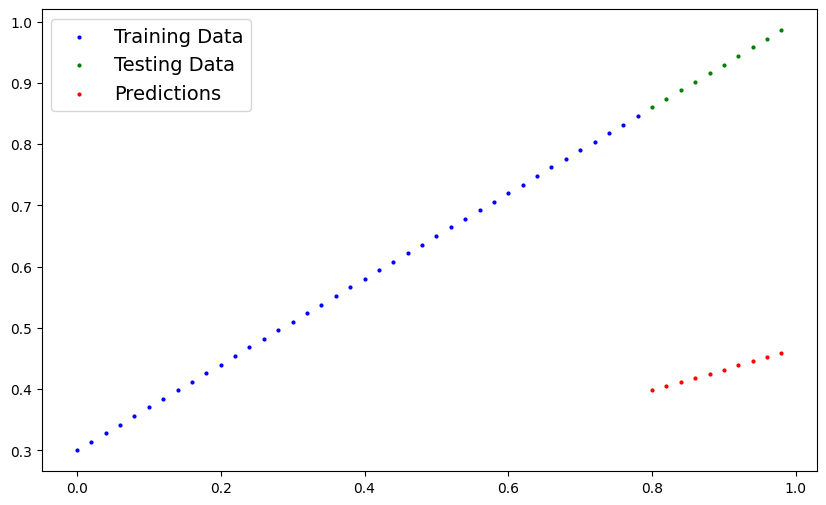

In [11]:
plot_predictions(predictions = y_pred)

## Setting Up the Loss Function and Optimizer

`L1Loss` (Mean Absolute Error) measures how far off the predictions are.
The `SGD` optimizer uses that error to nudge the weight and bias in the
right direction on each step.

In [12]:
#setting up a loss fucntion
loss_fn = nn.L1Loss()

#setup an optimizer
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr=0.01)

## Training the Model

Each epoch repeats the same cycle: forward pass → calculate loss →
backpropagate → update parameters. Tracking both train and test loss lets
us see if the model is actually learning or just overfitting.

In [13]:
epochs = 200

epoch_count = []
loss_values = []
test_loss_values=[]

for epoch in range(epochs):

  model_0.train()

  y_pred = model_0(X_train)

  loss = loss_fn(y_pred,y_train)
  print(f"Loss : {loss}")

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_0.eval()
  with torch.inference_mode():

    test_pred = model_0(X_test)

    test_loss = loss_fn(test_pred,y_test)


  if epoch%10==0:

    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)


    print(f"\nEpoch : {epoch} | Loss:{loss} | Test Loss : {test_loss}")
    print(f"{list(model_0.parameters())}\n")




Loss : 0.31288135051727295

Epoch : 0 | Loss:0.31288135051727295 | Test Loss : 0.48106518387794495
[Parameter containing:
tensor([0.3406], requires_grad=True), Parameter containing:
tensor([0.1388], requires_grad=True)]

Loss : 0.3013603687286377
Loss : 0.28983935713768005
Loss : 0.2783183455467224
Loss : 0.26679736375808716
Loss : 0.2552763521671295
Loss : 0.24375534057617188
Loss : 0.23223432898521423
Loss : 0.22071333229541779
Loss : 0.20919232070446014
Loss : 0.1976713389158249

Epoch : 10 | Loss:0.1976713389158249 | Test Loss : 0.3463551998138428
[Parameter containing:
tensor([0.3796], requires_grad=True), Parameter containing:
tensor([0.2388], requires_grad=True)]

Loss : 0.18615034222602844
Loss : 0.1746293157339096
Loss : 0.16310831904411316
Loss : 0.1515873372554779
Loss : 0.14006635546684265
Loss : 0.1285453587770462
Loss : 0.11702437698841095
Loss : 0.1060912162065506
Loss : 0.09681284427642822
Loss : 0.08908725529909134

Epoch : 20 | Loss:0.08908725529909134 | Test Loss : 0

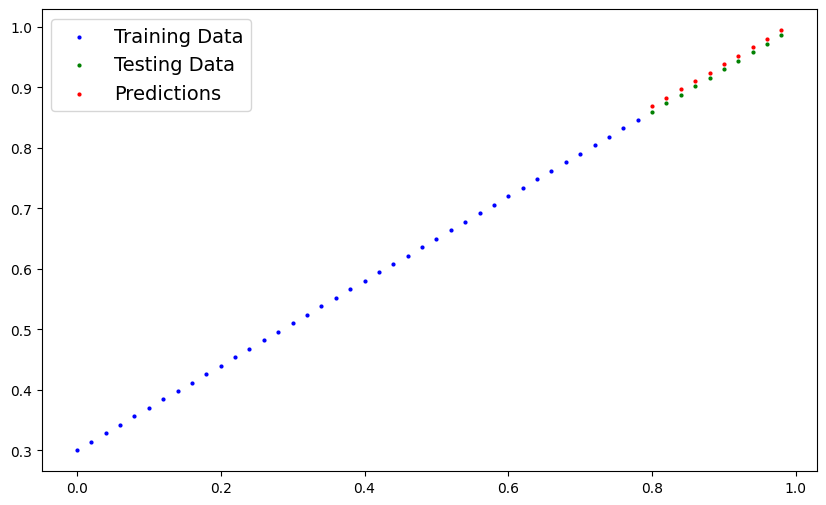

In [14]:
with torch.inference_mode():

  y_pred_new = model_0(X_test)

plot_predictions(predictions=y_pred_new)

## Visualizing the Loss Curve

If training is working, both train and test loss should drop and flatten
out. A test loss that stays high or increases would signal overfitting.

/var/folders/qj/_3231_qs7kg10g1x02_68b540000gn/T/ipykernel_66948/891262760.py:1: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:839.)
  plt.plot(epoch_count,np.array(torch.tensor(loss_values)),label="Train Loss")
/var/folders/qj/_3231_qs7kg10g1x02_68b540000gn/T/ipykernel_66948/891262760.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  plt.plot(epoch_count,np.array(torch.tensor(loss_values)),label="Train Loss")


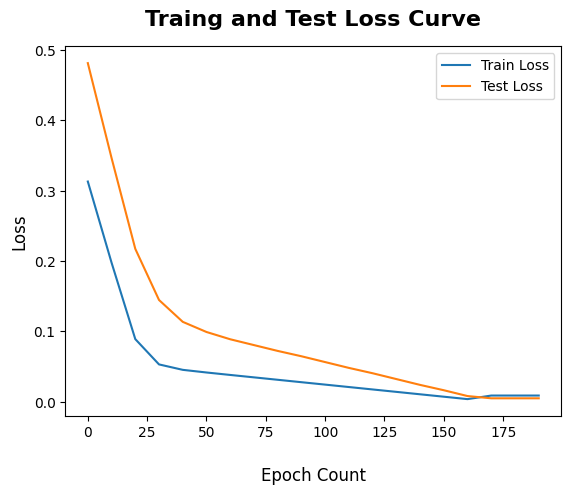

In [15]:
plt.plot(epoch_count,np.array(torch.tensor(loss_values)),label="Train Loss")
plt.plot(epoch_count,test_loss_values,label="Test Loss")
plt.title("Traing and Test Loss Curve",fontsize=16,fontweight="bold",pad=15)
plt.xlabel("\nEpoch Count",fontsize=12)
plt.ylabel("Loss",fontsize=12)
plt.legend()
plt.show()

# Saving the Model

Saving the trained weights (`state_dict`) means we don't have to retrain
from scratch every time we want to use this model.

In [16]:
from pathlib import Path

MODEL_PATH = Path("model")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

MODEL_NAME = "pytorch_,model_01.pth"

MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH

print(f"Saving model to : {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to : model/pytorch_,model_01.pth


# Loading the Model

Loading the saved `state_dict` into a fresh model instance and comparing
its predictions to the original confirms the save/load actually worked.

In [17]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [18]:
loaded_model_0 = LinearRegressionModel()

loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [19]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [20]:
loaded_model_0.eval()

with torch.inference_mode():
  loaded_model_preds=loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [21]:
y_pred_new == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## Key Learnings

- `nn.Parameter` is what makes a tensor trainable inside an `nn.Module` —
  this is exactly what `nn.Linear` does internally.
- `model.train()` and `model.eval()` matter because some layers behave
  differently during training vs inference.
- `torch.inference_mode()` skips gradient tracking, which is what you
  want when you're just predicting, not training.
- Saving/loading a `state_dict` is the standard way to persist a trained
  model in PyTorch.